# DiGToR - FMB Exploratory Data Analysis (EDA)

## 0a. Clone the repo (latest main)

In [ ]:
import os
REPO_NAME = "DiGToR"
REPO_URL  = "https://github.com/nguyenmaiductrong/DiGToR.git"
if os.path.isdir("digtor"):
    print("already inside the repo:", os.getcwd())
else:
    if not os.path.isdir(REPO_NAME):
        print("cloning", REPO_URL); os.system(f"git clone {REPO_URL}")
    os.chdir(REPO_NAME)
os.system("git pull origin main")
print("cwd:", os.getcwd())

cloning https://github.com/nguyenmaiductrong/DiGToR.git
cwd: /content/DiGToR


## 0. Config - edit these

In [ ]:
import sys
from pathlib import Path

DATASET = "fmb"
DATA_ROOT = "/kaggle/input/fmb/FMB"
HEIGHT, WIDTH = 384, 512
SEED = 42

REPO = Path.cwd()
if not (REPO / "digtor").exists():
    for cand in [REPO, REPO.parent, Path("/kaggle/working/DiGToR"),
                 Path("/content/DiGToR"), Path("/content/drive/MyDrive/DiGToR")]:
        if (cand / "digtor").exists():
            REPO = cand; break
sys.path.insert(0, str(REPO)); os.chdir(REPO)
EDA = REPO / "eda_assets"; EDA.mkdir(exist_ok=True)
print("repo     :", REPO)
print("data root:", DATA_ROOT, "->", "OK" if Path(DATA_ROOT).exists() else "MISSING (run 0b)")

repo     : /content/DiGToR
data root: /kaggle/input/fmb/FMB -> MISSING (run 0b)


## 0b. Auto-download FMB from Google Drive (idempotent)

In [ ]:
import glob, zipfile, shutil, subprocess

def _have(p):
    return bool(p) and Path(p).exists() and any(Path(p).rglob("*"))

if not _have(DATA_ROOT):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
    import gdown
    base = "/content" if Path("/content").is_dir() else str(REPO.parent)
    URL = "https://drive.google.com/drive/folders/1T_jVi80tjgyHTQDpn-TjfySyW4CK1LlF"
    DATA_ROOT = f"{base}/FMB"; mods = ("Visible", "Infrared", "Label")
    ready = lambda: all((Path(DATA_ROOT) / s / m).is_dir()
                        for s in ("train", "test") for m in mods)
    if not ready():
        dl = str(REPO / "_dl"); shutil.rmtree(dl, ignore_errors=True)
        gdown.download_folder(URL, output=dl, quiet=False, use_cookies=False)
        find = lambda n: glob.glob(f"{dl}/**/{n}", recursive=True)[0]
        def _modroot(b):
            for r, _, _ in os.walk(b):
                if all((Path(r) / m).is_dir() for m in mods): return r
            raise FileNotFoundError("no Visible/Infrared/Label under " + b)
        for sp in ("train", "test"):
            tmp = str(REPO / f"_uz_{sp}"); shutil.rmtree(tmp, ignore_errors=True)
            with zipfile.ZipFile(find(f"{sp}.zip")) as z: z.extractall(tmp)
            dst = f"{DATA_ROOT}/{sp}"; shutil.rmtree(dst, ignore_errors=True)
            shutil.move(_modroot(tmp), dst); shutil.rmtree(tmp, ignore_errors=True)
        shutil.rmtree(dl, ignore_errors=True)
print("DATA_ROOT =", DATA_ROOT, "->", "OK" if _have(DATA_ROOT) else "MISSING")

Retrieving folder contents


Processing file 1AamLVgMG5JCkhUOZi-xKTymZXCNklnaq test.zip
Processing file 1nk2R2yZ05SDe2lDpsk2D5RAngMBPUPsB train.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1AamLVgMG5JCkhUOZi-xKTymZXCNklnaq
From (redirected): https://drive.google.com/uc?id=1AamLVgMG5JCkhUOZi-xKTymZXCNklnaq&confirm=t&uuid=8a89b34e-0c77-4d4f-a6b1-2b6a431fe9c5
To: /content/DiGToR/_dl/test.zip
100%|██████████| 216M/216M [00:04<00:00, 45.9MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1nk2R2yZ05SDe2lDpsk2D5RAngMBPUPsB
From (redirected): https://drive.google.com/uc?id=1nk2R2yZ05SDe2lDpsk2D5RAngMBPUPsB&confirm=t&uuid=ecc66c90-7592-4a56-bf06-4ca37a7178bf
To: /content/DiGToR/_dl/train.zip
100%|██████████| 914M/914M [00:10<00:00, 89.7MB/s]
Download completed


DATA_ROOT = /content/FMB -> OK


## 1. Setup + full dataset scan
Imports the real adapter (class names, luminance/condition proxy, corruptions) and scans every
image once: per-class pixel counts (native resolution = true label distribution), visible
luminance, thermal intensity, and the unlabelled-pixel fraction.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image
from collections import Counter

from digtor import IGNORE_INDEX, get_dataset_config, get_dataset_module
from digtor.dataset.fmb import (luminance, condition_of, has_official_split,
                                _rgb_to_tensor, _ir_to_tensor,
                                IMAGENET_MEAN, IMAGENET_STD)
from digtor.metrics import corrupt_visible, corrupt_thermal

cfg = get_dataset_config(DATASET); ds = get_dataset_module(DATASET)
CLASS_NAMES = cfg.class_names; NC = cfg.num_classes
ROOT = Path(DATA_ROOT); official = has_official_split(ROOT)
split = ds.deterministic_split(str(ROOT), seed=SEED)
print(f"classes ({NC}):", CLASS_NAMES)
print("official split:", official, "| sizes:", {k: len(v) for k, v in split.items()})

def _pool(part):
    d = ROOT / part / "Label" if official else ROOT / "Label"
    return (part if official else None), sorted(os.listdir(d))

def scan(part):
    partition, names = _pool(part)
    base = ROOT / partition if partition else ROOT
    recs, cls_px, cls_img = [], np.zeros(256, np.int64), np.zeros(256, np.int64)
    for n in names:
        lab = np.asarray(Image.open(base / "Label" / n).convert("L"))
        b = np.bincount(lab.ravel(), minlength=256); cls_px += b
        cls_img += (b > 0).astype(np.int64)
        ml, sl = luminance(Image.open(base / "Visible" / n))
        ir = np.asarray(Image.open(base / "Infrared" / n).convert("L"), np.float32) / 255.0
        recs.append(dict(name=n, part=part, lum=ml, lum_std=sl, cond=condition_of(ml, sl),
                         ir_mean=float(ir.mean()), ir_std=float(ir.std()),
                         unlab_frac=float(b[0]) / max(b.sum(), 1)))
    return recs, cls_px, cls_img

train_recs, train_px, train_img = scan("train")
if official:
    test_recs, test_px, test_img = scan("test")
else:
    test_recs, test_px, test_img = [], np.zeros(256, np.int64), np.zeros(256, np.int64)
N_train, N_test = len(train_recs), len(test_recs)
print(f"scanned -> train {N_train} imgs, test {N_test} imgs")

classes (15): ['unlabelled', 'road', 'sidewalk', 'building', 'lamp', 'sign', 'vegetation', 'sky', 'person', 'car', 'truck', 'bus', 'motorcycle', 'bicycle', 'pole']
official split: True | sizes: {'train': 1092, 'val': 128, 'test': 280}
scanned -> train 1220 imgs, test 280 imgs


## 2. Class imbalance
Per-class pixel share (log-scale) on train vs test, the head:tail ratio, and the background
(`unlabelled`) share. This is what motivates the focal-style loss (`gamma_prior=2.0`) and the
FWIoU metric, and why class-0 handling matters.

,class,train_%,test_%,train_imgs,test_imgs,imbalance_x
0,sky,35.863,32.522,1206,277,1.0
1,vegetation,24.022,23.485,1192,278,1.5
2,building,15.043,19.621,1054,279,2.4
3,road,13.451,11.331,1187,268,2.7
4,car,5.149,5.842,1141,271,7.0
5,unlabelled,1.936,1.413,1210,280,18.5
6,sidewalk,1.573,1.596,779,198,22.8
7,pole,1.533,1.671,1103,267,23.4
8,truck,0.365,0.382,167,50,98.3
9,bus,0.342,0.854,213,58,105.0


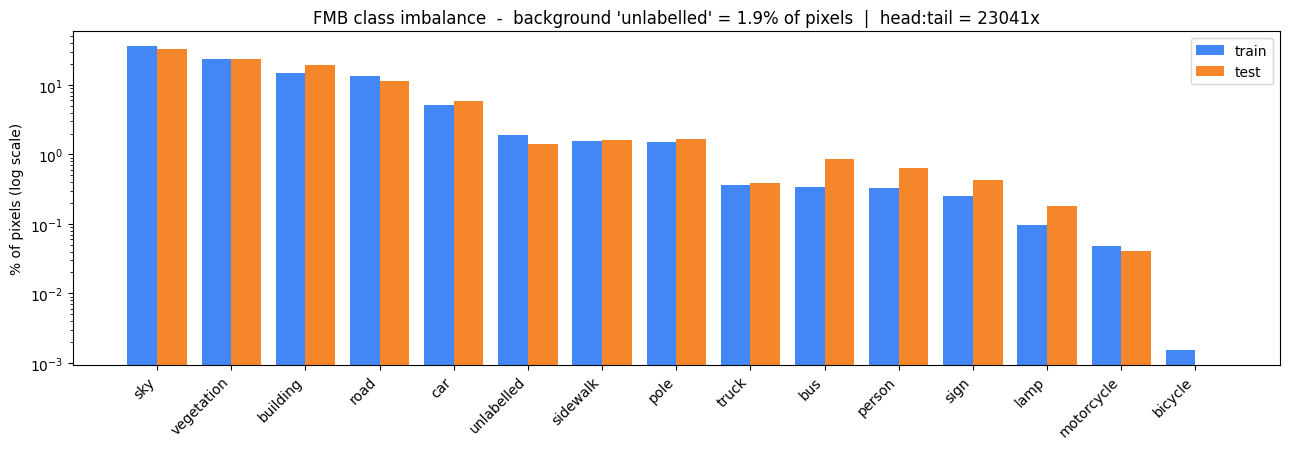

raw 255-ignore pixels: train=0, test=0


In [ ]:
def frac(px): return px[:NC] / max(px[:NC].sum(), 1)
ftr = frac(train_px); fte = frac(test_px) if N_test else frac(train_px)
order = np.argsort(-ftr)                                  # most frequent first

imb = pd.DataFrame({
    "class":      [CLASS_NAMES[i] for i in order],
    "train_%":    (ftr[order] * 100).round(3),
    "test_%":     (fte[order] * 100).round(3),
    "train_imgs": [int(train_img[i]) for i in order],
    "test_imgs":  [int(test_img[i]) for i in order],
})
imb["imbalance_x"] = (ftr[order].max() / np.clip(ftr[order], 1e-12, None)).round(1)
imb.to_csv(EDA / "eda_class_imbalance.csv", index=False)
display(imb)

x = np.arange(NC); w = 0.4
plt.figure(figsize=(13, 4.6))
plt.bar(x - w/2, ftr[order]*100, w, label="train", color="#4287f5")
plt.bar(x + w/2, fte[order]*100, w, label="test",  color="#f5872a")
plt.yscale("log"); plt.ylabel("% of pixels (log scale)")
plt.xticks(x, [CLASS_NAMES[i] for i in order], rotation=45, ha="right")
plt.title(f"FMB class imbalance  -  background '{CLASS_NAMES[0]}' = {ftr[0]*100:.1f}% of pixels  |  "
          f"head:tail = {ftr.max()/ftr[ftr>0].min():.0f}x")
plt.legend(); plt.tight_layout()
plt.savefig(EDA / "eda_class_imbalance.png", dpi=200, bbox_inches="tight"); plt.show()
print(f"raw 255-ignore pixels: train={int(train_px[255])}, test={int(test_px[255])}")

## 3. Acquisition conditions & noise (the model's own proxy)
The adapter labels each frame day/night/fog from visible luminance (`condition_of`, the exact
heuristic the routing eval uses). Imbalanced conditions are *why* thermal matters: low-light
frames are where RGB fails and thermal rescues.

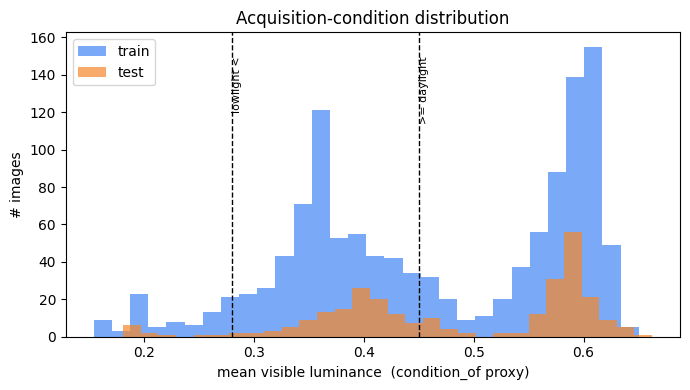

,condition,train,test
0,daylight,319,78
1,other,518,109
2,lowlight,79,12
3,fog,304,81


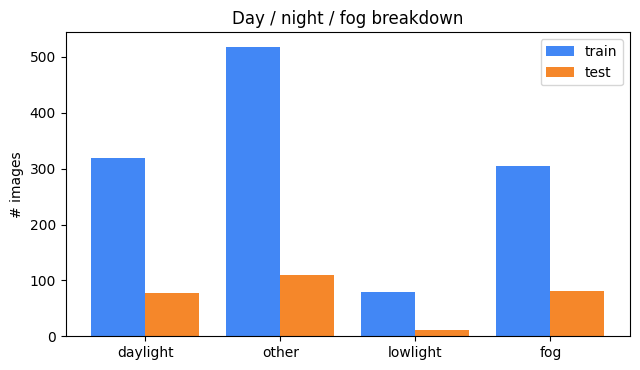

In [ ]:
allr = train_recs + test_recs
w = 0.4
plt.figure(figsize=(7, 4))
plt.hist([r["lum"] for r in train_recs], bins=30, alpha=.7, label="train", color="#4287f5")
if N_test: plt.hist([r["lum"] for r in test_recs], bins=30, alpha=.7, label="test", color="#f5872a")
for thr, lab in [(0.28, "lowlight <"), (0.45, ">= daylight")]:
    plt.axvline(thr, color="k", ls="--", lw=1)
    plt.text(thr, plt.ylim()[1]*.92, lab, rotation=90, va="top", fontsize=8)
plt.xlabel("mean visible luminance  (condition_of proxy)"); plt.ylabel("# images")
plt.title("Acquisition-condition distribution"); plt.legend(); plt.tight_layout()
plt.savefig(EDA / "eda_luminance.png", dpi=200, bbox_inches="tight"); plt.show()

order_c = ["daylight", "other", "lowlight", "fog"]
ct_tr, ct_te = Counter(r["cond"] for r in train_recs), Counter(r["cond"] for r in test_recs)
cdf = pd.DataFrame({"condition": order_c,
                    "train": [ct_tr.get(c, 0) for c in order_c],
                    "test":  [ct_te.get(c, 0) for c in order_c]})
display(cdf); cdf.to_csv(EDA / "eda_conditions.csv", index=False)

xc = np.arange(len(order_c))
plt.figure(figsize=(6.5, 3.8))
plt.bar(xc - w/2, cdf["train"], w, label="train", color="#4287f5")
plt.bar(xc + w/2, cdf["test"],  w, label="test",  color="#f5872a")
plt.xticks(xc, order_c); plt.ylabel("# images"); plt.title("Day / night / fog breakdown")
plt.legend(); plt.tight_layout(); plt.savefig(EDA / "eda_conditions.png", dpi=200, bbox_inches="tight"); plt.show()

## 4. Corruption protocol preview (faithful to `digtor/metrics.py`)
The *exact* ops used by `corrupt_aug` during DiGToR training and by `eval_robustness` at test
time, run on one real daylight frame. This is the project's noise model - not a generic one.

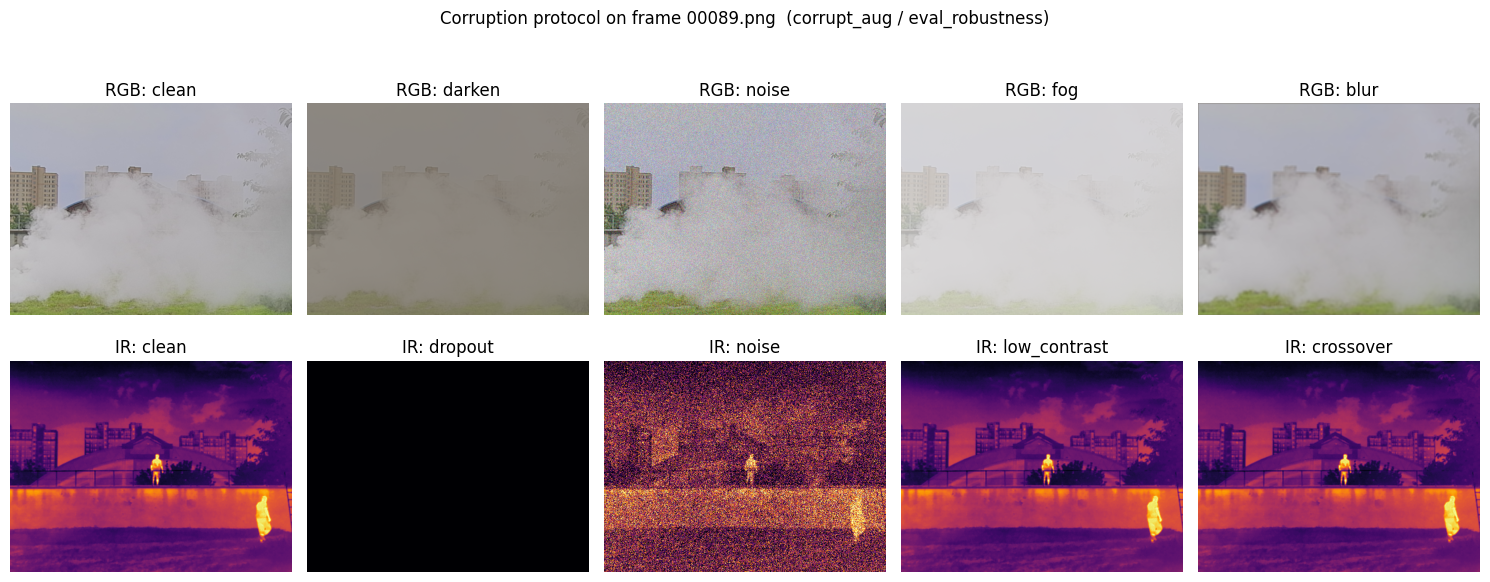

In [ ]:
def denorm_rgb(t):
    a = t[0].cpu().numpy().transpose(1, 2, 0) * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(a, 0, 1)
def denorm_ir(t):
    return np.clip(t[0, 0].cpu().numpy() * 0.5 + 0.5, 0, 1)

recs = test_recs if N_test else train_recs
part = "test" if (official and N_test) else ("train" if official else None)
base = ROOT / part if part else ROOT
sample = sorted(recs, key=lambda r: -r["lum"])[0]["name"]            # a bright frame
size = (WIDTH, HEIGHT)
rgb = _rgb_to_tensor(Image.open(base / "Visible" / sample), size)[None]
ir  = _ir_to_tensor(Image.open(base / "Infrared" / sample), size)[None]
g = torch.Generator().manual_seed(0)

vis = [("clean", rgb)] + [(k, corrupt_visible(rgb, k, s, gen=g))
       for k, s in [("darken", 0.7), ("noise", 0.3), ("fog", 0.7), ("blur", 0.0)]]
th  = [("clean", ir)] + [(k, corrupt_thermal(ir, k, s, gen=g))
       for k, s in [("dropout", 1.0), ("noise", 0.6), ("low_contrast", 0.8), ("crossover", 0.8)]]

fig, ax = plt.subplots(2, len(vis), figsize=(3*len(vis), 6))
for j, (k, t) in enumerate(vis):
    ax[0, j].imshow(denorm_rgb(t)); ax[0, j].set_title(f"RGB: {k}"); ax[0, j].axis("off")
for j, (k, t) in enumerate(th):
    ax[1, j].imshow(denorm_ir(t), cmap="inferno"); ax[1, j].set_title(f"IR: {k}"); ax[1, j].axis("off")
plt.suptitle(f"Corruption protocol on frame {sample}  (corrupt_aug / eval_robustness)", y=1.02)
plt.tight_layout(); plt.savefig(EDA / "eda_corruptions.png", dpi=200, bbox_inches="tight"); plt.show()

## 5. Outliers / edge cases
The extremes the model must survive: the darkest RGB frame, a low-contrast (fog-like) frame,
a thermally saturated frame, and the frame with the most unlabelled pixels.

darkest RGB (low-light)            00598.png            lum=0.15 ir=0.21 unlab=   6%
brightest low-contrast (fog-like)  00089.png            lum=0.66 ir=0.34 unlab=   1%
thermal saturated (high IR)        00330.png            lum=0.56 ir=0.45 unlab=   2%
most unlabelled pixels             00081.png            lum=0.59 ir=0.33 unlab=  30%


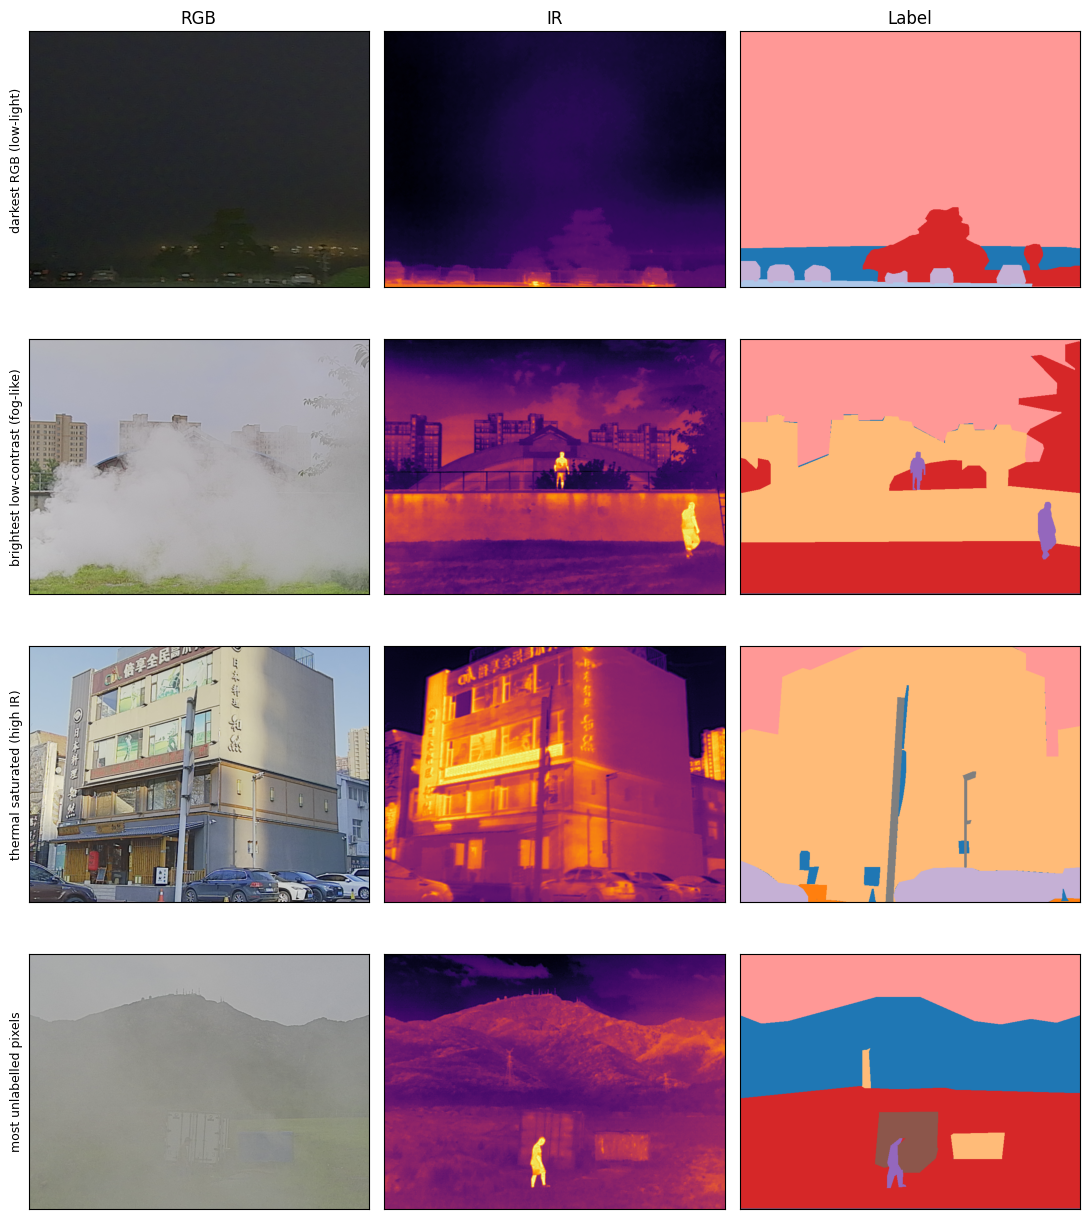

In [ ]:
def colorize(lbl):
    cmap = (plt.get_cmap("tab20")(np.arange(NC) % 20)[:, :3] * 255).astype(np.uint8)
    out = np.zeros((*lbl.shape, 3), np.uint8); m = (lbl >= 0) & (lbl < NC); out[m] = cmap[lbl[m]]
    return out
def base_of(r): return (ROOT / r["part"]) if official else ROOT

recs = train_recs + test_recs
fogish = [r for r in recs if r["lum_std"] < 0.13] or recs
picks = [
    ("darkest RGB (low-light)",          min(recs, key=lambda r: r["lum"])),
    ("brightest low-contrast (fog-like)", max(fogish, key=lambda r: r["lum"])),
    ("thermal saturated (high IR)",       max(recs, key=lambda r: r["ir_mean"])),
    ("most unlabelled pixels",            max(recs, key=lambda r: r["unlab_frac"])),
]
fig, ax = plt.subplots(len(picks), 3, figsize=(11, 3.2*len(picks)))
for i, (tag, r) in enumerate(picks):
    b = base_of(r)
    rgb = np.asarray(Image.open(b / "Visible" / r["name"]).convert("RGB"))
    ir  = np.asarray(Image.open(b / "Infrared" / r["name"]).convert("L"))
    lab = np.asarray(Image.open(b / "Label" / r["name"]).convert("L"))
    ax[i, 0].imshow(rgb); ax[i, 0].set_ylabel(tag, fontsize=9)
    ax[i, 1].imshow(ir, cmap="inferno"); ax[i, 2].imshow(colorize(lab))
    if i == 0:
        for j, t in enumerate(["RGB", "IR", "Label"]): ax[i, j].set_title(t)
    for j in range(3): ax[i, j].set_xticks([]); ax[i, j].set_yticks([])
    print(f"{tag:34s} {r['name']:20s} lum={r['lum']:.2f} ir={r['ir_mean']:.2f} unlab={r['unlab_frac']*100:4.0f}%")
plt.tight_layout(); plt.savefig(EDA / "eda_outliers.png", dpi=200, bbox_inches="tight"); plt.show()

## 6. Preprocessing strategy (exact, read from the code)
Every transform below is the literal pipeline in `digtor/dataset/fmb.py` - nothing invented.

In [ ]:
prep = pd.DataFrame([
    ("Visible (RGB)",  f"convert RGB -> resize {HEIGHT}x{WIDTH} BILINEAR -> /255 -> "
                       f"normalize ImageNet mean={tuple(IMAGENET_MEAN)} std={tuple(IMAGENET_STD)}"),
    ("Infrared (IR)",  "convert L (1 channel) -> resize BILINEAR -> /255 -> (x-0.5)/0.5  => range [-1, 1]"),
    ("Label",          f"convert L -> resize NEAREST (no interpolation) -> int64;  ignore_index={IGNORE_INDEX}"),
    ("Augment (train)","random horizontal flip p=0.5  (+ corrupt_aug p=0.5 during DiGToR training)"),
    ("Split",          "official train/ + held-out test/;  val = block-shuffled 10% cut of train "
                       "(block=16, seed=42) -> no scene/near-duplicate leakage"),
    ("Imbalance",      "focal-style loss gamma_prior=2.0; FWIoU reported; "
                       "FMB keeps class-0 'unlabelled', SemanticRT folds it into ignore"),
], columns=["stream", "preprocessing (verbatim from digtor/dataset/fmb.py)"])
pd.set_option("display.max_colwidth", None); display(prep)
prep.to_csv(EDA / "eda_preprocessing.csv", index=False)
print("split sizes:", {k: len(v) for k, v in split.items()})

,stream,preprocessing (verbatim from digtor/dataset/fmb.py)
0,Visible (RGB),"convert RGB -> resize 384x512 BILINEAR -> /255 -> normalize ImageNet mean=(0.485, 0.456, 0.406) std=(0.229, 0.224, 0.225)"
1,Infrared (IR),"convert L (1 channel) -> resize BILINEAR -> /255 -> (x-0.5)/0.5 => range [-1, 1]"
2,Label,convert L -> resize NEAREST (no interpolation) -> int64; ignore_index=255
3,Augment (train),random horizontal flip p=0.5 (+ corrupt_aug p=0.5 during DiGToR training)
4,Split,"official train/ + held-out test/; val = block-shuffled 10% cut of train (block=16, seed=42) -> no scene/near-duplicate leakage"
5,Imbalance,"focal-style loss gamma_prior=2.0; FWIoU reported; FMB keeps class-0 'unlabelled', SemanticRT folds it into ignore"


split sizes: {'train': 1092, 'val': 128, 'test': 280}


---
### Outputs (`eda_assets/`)
- `eda_class_imbalance.png` + `.csv` - per-class pixel/image frequency, head:tail ratio
- `eda_luminance.png`, `eda_conditions.png` + `.csv` - day/night/fog condition breakdown
- `eda_corruptions.png` - the faithful corruption protocol (corrupt_aug / eval_robustness)
- `eda_outliers.png` - edge cases (dark / fog / thermal-saturated / unlabelled)
- `eda_preprocessing.csv` - the exact transform table

All derived from raw images only - no checkpoints required.